# Equity Model Comparison — Variant Selection

**Instruments:** `nq1s` (XGB), `fesx1s` (Logistic elastic-net), `es1s` (RF — exploratory)

**Discipline:**
- Phase 1 selection on **TRAIN** only via CPCV (n=6, k=2, embargo=0.01 → 15 paths)
- **LOCKED pick committed to CSV before Phase 2 begins**
- Phase 2: single-shot OOS on sealed test; run once
- Non-locked variants in Phase 2 are **diagnostic only — never used for re-selection**
- PCA fitted per fold on TRAIN rows; test rows transformed, never fitted


In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')
from IPython.display import Image, display

BASE = Path('outputs/model_comparison/equity')

def show(path, width=950):
    p = Path(path)
    if p.exists():
        display(Image(str(p), width=width))

def load(path):
    p = Path(path)
    return pd.read_csv(p) if p.exists() else pd.DataFrame()

cpcv_df   = load(BASE / 'cpcv_results.csv')
locked_df = load(BASE / 'locked_picks.csv')
oos_df    = load(BASE / 'oos_results.csv')
locked_picks = locked_df.set_index('inst')['locked_variant'].to_dict() if not locked_df.empty else {}
print('Locked picks:', locked_picks)


Locked picks: {'nq1s': 'reduced', 'fesx1s': 'reduced', 'es1s': 'pruned'}


## Variant Definitions

Each instrument uses one champion model family (fixed; no retuning). Three feature sets compete.

| Instrument | Family | Full | Pruned | Reduced |
|---|---|---|---|---|
| `nq1s` | XGB | All ~100 features | F5\_signal + C4\_f11 (10 features) | `f5_signal`, `f11_dist_stock_surprise`, `f11_copper_stock_z`, `f11_vix_5d_change` (4 raw) |
| `fesx1s` | Logistic | All ~100 features | F5\_signal + C10\_f12 + C13\_f7 (12 features) | PC1–PC4 of F5\_signal + 4 raw features = **8 inputs** |
| `es1s` | RF | All ~100 features | F5\_signal + C14\_f11 + C2\_f2 (28 features) | PC1+PC2 of C14\_f11, PC1+PC2 of C2\_f2, `f5_trailing_run_length`, `f7_oi_z_20` = **6 inputs** |

> **fesx1s reduced rationale:** PC1–PC4 of F5\_signal explain **90.9%** of the cluster's
> variance (PC1=36.1% sustained momentum, PC2=20.6% MR-signal agreement, PC3=18.8%
> participation rate, PC4=15.5% fresh-signal divergence). See `equity_importance.ipynb`
> Step 3 for the full loadings matrix.

> **PCA discipline:** `StandardScaler → PCA` fitted on training rows only per CPCV fold
> (Phase 1) and on the full training set (Phase 2). Test rows are transformed only.


---
## Phase 1 — CPCV Variant Scoring (TRAIN only)

CPCV n_groups=6, k=2, embargo=0.01 → 15 test paths. Metrics: mean ± std AUC across paths.

**1SE lock rule:** threshold = full\_mean − full\_SE. The simplest variant  
(reduced < pruned < full) whose mean AUC ≥ threshold is locked.


In [2]:
if not cpcv_df.empty:
    SIMP = {'reduced': 0, 'pruned': 1, 'full': 2}
    fmt = {
        'auc_mean': '{:.4f}', 'auc_std': '{:.4f}', 'auc_se': '{:.4f}',
        'logloss': '{:.4f}', 'brier': '{:.4f}',
    }
    def _hl(row):
        locked = locked_picks.get(row['inst'], '')
        return ['background-color: #C8E6C9' if row['variant'] == locked else '' for _ in row]
    ordered = (
        cpcv_df.copy()
        .assign(simplicity=lambda d: d['variant'].map(SIMP))
        .sort_values(['inst', 'simplicity'])
        .drop(columns='simplicity')
    )
    display(
        ordered[['inst','variant','auc_mean','auc_std','auc_se','logloss','brier','n_paths']]
        .style.format(fmt)
        .apply(_hl, axis=1)
        .set_caption('Phase 1 CPCV — all variants (green = locked per 1SE rule)')
    )


,inst,variant,auc_mean,auc_std,auc_se,logloss,brier,n_paths
8,es1s,reduced,0.5804,0.0455,0.0118,0.6911,0.2489,15
7,es1s,pruned,0.6014,0.0345,0.0089,0.6866,0.2466,15
6,es1s,full,0.5946,0.0303,0.0078,0.6815,0.2442,15
5,fesx1s,reduced,0.5502,0.0348,0.0090,0.6912,0.2489,15
4,fesx1s,pruned,0.5413,0.0331,0.0086,0.6906,0.2488,15
3,fesx1s,full,0.5054,0.0282,0.0073,0.7734,0.2716,15
2,nq1s,reduced,0.6071,0.0246,0.0064,0.6780,0.2423,15
1,nq1s,pruned,0.5295,0.0411,0.0106,0.6920,0.2494,15
0,nq1s,full,0.5802,0.0328,0.0085,0.6849,0.2459,15


### NQ1S — XGB


,variant,auc_mean,auc_std,auc_se,logloss,brier
0,full,0.5802,0.0328,0.0085,0.6849,0.2459
1,pruned,0.5295,0.0411,0.0106,0.6920,0.2494
2,reduced,0.6071,0.0246,0.0064,0.6780,0.2423


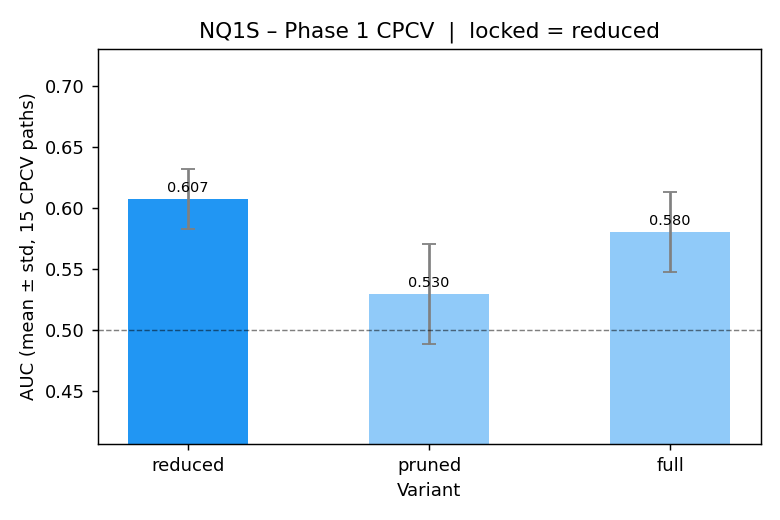

In [3]:
_inst = 'nq1s'
_locked = locked_picks.get(_inst, 'full')
_rows = cpcv_df[cpcv_df['inst'] == _inst] if not cpcv_df.empty else pd.DataFrame()
_fmt2 = {'auc_mean': '{:.4f}', 'auc_std': '{:.4f}', 'auc_se': '{:.4f}', 'logloss': '{:.4f}', 'brier': '{:.4f}'}
if not _rows.empty:
    display(
        _rows[['variant','auc_mean','auc_std','auc_se','logloss','brier']]
        .style.format(_fmt2)
        .apply(lambda row: ['background-color: #C8E6C9' if row['variant'] == _locked else '' for _ in row], axis=1)
        .set_caption(_inst.upper() + ' Phase 1 CPCV (green = locked: ' + _locked + ')')
    )
show(BASE / ('nq1s_cpcv_chart.png'), width=700)


### FESX1S — Logistic


,variant,auc_mean,auc_std,auc_se,logloss,brier
3,full,0.5054,0.0282,0.0073,0.7734,0.2716
4,pruned,0.5413,0.0331,0.0086,0.6906,0.2488
5,reduced,0.5502,0.0348,0.0090,0.6912,0.2489


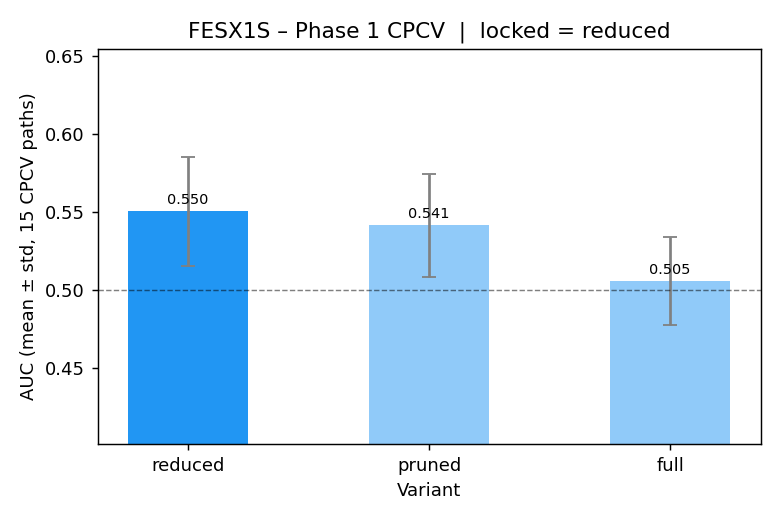

In [4]:
_inst = 'fesx1s'
_locked = locked_picks.get(_inst, 'full')
_rows = cpcv_df[cpcv_df['inst'] == _inst] if not cpcv_df.empty else pd.DataFrame()
_fmt2 = {'auc_mean': '{:.4f}', 'auc_std': '{:.4f}', 'auc_se': '{:.4f}', 'logloss': '{:.4f}', 'brier': '{:.4f}'}
if not _rows.empty:
    display(
        _rows[['variant','auc_mean','auc_std','auc_se','logloss','brier']]
        .style.format(_fmt2)
        .apply(lambda row: ['background-color: #C8E6C9' if row['variant'] == _locked else '' for _ in row], axis=1)
        .set_caption(_inst.upper() + ' Phase 1 CPCV (green = locked: ' + _locked + ')')
    )
show(BASE / ('fesx1s_cpcv_chart.png'), width=700)


### ES1S — RF ⚠️ EXPLORATORY — no confirmed signal


,variant,auc_mean,auc_std,auc_se,logloss,brier
6,full,0.5946,0.0303,0.0078,0.6815,0.2442
7,pruned,0.6014,0.0345,0.0089,0.6866,0.2466
8,reduced,0.5804,0.0455,0.0118,0.6911,0.2489


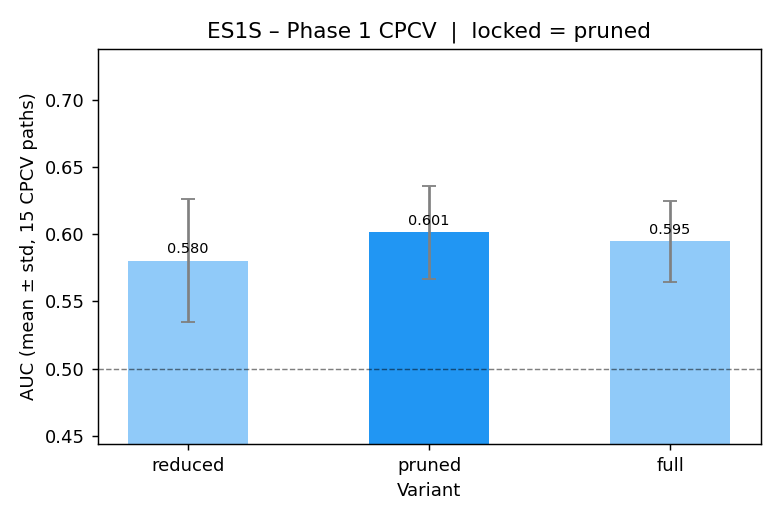

In [5]:
_inst = 'es1s'
_locked = locked_picks.get(_inst, 'full')
_rows = cpcv_df[cpcv_df['inst'] == _inst] if not cpcv_df.empty else pd.DataFrame()
_fmt2 = {'auc_mean': '{:.4f}', 'auc_std': '{:.4f}', 'auc_se': '{:.4f}', 'logloss': '{:.4f}', 'brier': '{:.4f}'}
if not _rows.empty:
    display(
        _rows[['variant','auc_mean','auc_std','auc_se','logloss','brier']]
        .style.format(_fmt2)
        .apply(lambda row: ['background-color: #C8E6C9' if row['variant'] == _locked else '' for _ in row], axis=1)
        .set_caption(_inst.upper() + ' Phase 1 CPCV (green = locked: ' + _locked + ')')
    )
show(BASE / ('es1s_cpcv_chart.png'), width=700)


---
## Locked Picks (committed before Phase 2)

> These picks were written to `locked_picks.csv` **before the sealed test was read**.
> They cannot be revised based on OOS outcomes.


In [6]:
if not locked_df.empty:
    display(
        locked_df.style
        .set_properties(**{'background-color': '#C8E6C9', 'font-weight': 'bold'})
        .hide(axis='index')
        .set_caption('Locked variant per instrument — 1SE rule on TRAIN CPCV')
    )
print()
for inst, variant in locked_picks.items():
    c_row = cpcv_df[(cpcv_df['inst']==inst) & (cpcv_df['variant']==variant)]
    if not c_row.empty:
        r = c_row.iloc[0]
        print(f'  {inst:8s}  LOCKED = {variant:8s}  dev-CPCV AUC = {r["auc_mean"]:.4f} ± {r["auc_std"]:.4f}')


inst,locked_variant
nq1s,reduced
fesx1s,reduced
es1s,pruned



  nq1s      LOCKED = reduced   dev-CPCV AUC = 0.6071 ± 0.0246
  fesx1s    LOCKED = reduced   dev-CPCV AUC = 0.5502 ± 0.0348
  es1s      LOCKED = pruned    dev-CPCV AUC = 0.6014 ± 0.0345


---
## Phase 2 — Single-Shot OOS (Sealed Test)

Test window: `date > 2021-10-20` (embargo end). Scored **once**.

- **Headline** = locked variant OOS result
- **Diagnostic block** = non-locked variants shown for transparency; never used for re-selection


,inst,variant,is_locked,auc,auc_ci_lo,auc_ci_hi,logloss,brier,n_test
0,nq1s,full,False,0.5408,0.451,0.625,0.6891,0.2480,171
1,nq1s,pruned,False,0.4595,0.374,0.553,0.7033,0.2550,171
2,nq1s,reduced,True,0.5215,0.434,0.612,0.6962,0.2513,171
3,fesx1s,full,False,0.5268,0.442,0.609,0.6955,0.2512,176
4,fesx1s,pruned,False,0.5149,0.427,0.598,0.6966,0.2517,176
5,fesx1s,reduced,True,0.5248,0.436,0.609,0.6927,0.2498,176
6,es1s,full,False,0.5098,0.416,0.605,0.7193,0.2629,150
7,es1s,pruned,True,0.5044,0.415,0.601,0.7250,0.2657,150
8,es1s,reduced,False,0.5008,0.403,0.600,0.7084,0.2577,150


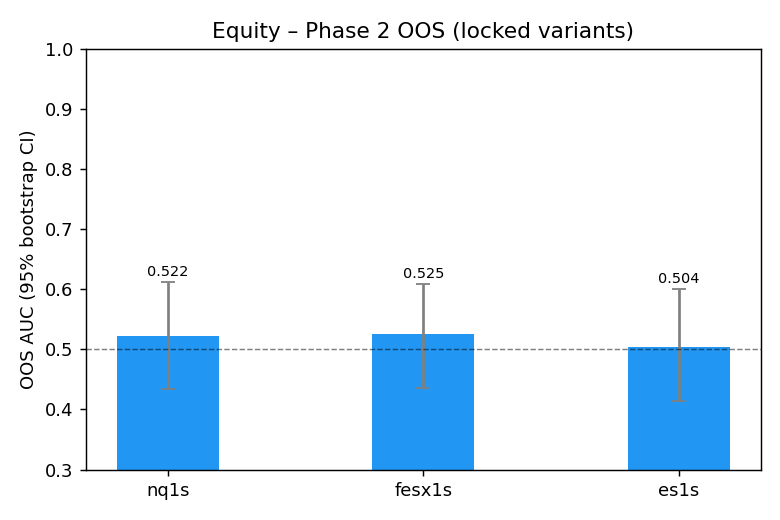

In [7]:
if not oos_df.empty:
    _oos_fmt = {'auc': '{:.4f}', 'auc_ci_lo': '{:.3f}', 'auc_ci_hi': '{:.3f}',
                'logloss': '{:.4f}', 'brier': '{:.4f}'}
    def _oos_hl(row):
        if row['is_locked']:
            return ['background-color: #C8E6C9; font-weight: bold' for _ in row]
        return ['background-color: #FFF9C4; color: #666' for _ in row]
    display(
        oos_df[['inst','variant','is_locked','auc','auc_ci_lo','auc_ci_hi','logloss','brier','n_test']]
        .style.format(_oos_fmt)
        .apply(_oos_hl, axis=1)
        .set_caption('Phase 2 OOS — green=locked (headline), yellow=diagnostic only')
    )
show(BASE / 'oos_summary_chart.png', width=700)


### Per-instrument Phase 2 detail


In [8]:
if not oos_df.empty:
    for inst in ['nq1s', 'fesx1s', 'es1s']:
        locked = locked_picks.get(inst, 'full')
        inst_oos   = oos_df[oos_df['inst'] == inst]
        locked_row = inst_oos[inst_oos['variant'] == locked]
        diag_rows  = inst_oos[inst_oos['variant'] != locked]
        print(f'\n{"="*55}')
        print(f'{inst.upper()} — LOCKED variant: {locked}')
        if not locked_row.empty:
            r = locked_row.iloc[0]
            print(f'  HEADLINE OOS AUC: {r["auc"]:.4f}  [{r["auc_ci_lo"]:.3f}, {r["auc_ci_hi"]:.3f}]')
            print(f'  logloss: {r["logloss"]:.4f}  brier: {r["brier"]:.4f}  n_test: {r["n_test"]}')
        print('  -- diagnostic (not used for selection) --')
        for _, r in diag_rows.iterrows():
            print(f'  {r["variant"]:8s}  AUC={r["auc"]:.4f} [{r["auc_ci_lo"]:.3f},{r["auc_ci_hi"]:.3f}]')



NQ1S — LOCKED variant: reduced
  HEADLINE OOS AUC: 0.5215  [0.434, 0.612]
  logloss: 0.6962  brier: 0.2513  n_test: 171
  -- diagnostic (not used for selection) --
  full      AUC=0.5408 [0.451,0.625]
  pruned    AUC=0.4595 [0.374,0.553]

FESX1S — LOCKED variant: reduced
  HEADLINE OOS AUC: 0.5248  [0.436, 0.609]
  logloss: 0.6927  brier: 0.2498  n_test: 176
  -- diagnostic (not used for selection) --
  full      AUC=0.5268 [0.442,0.609]
  pruned    AUC=0.5149 [0.427,0.598]

ES1S — LOCKED variant: pruned
  HEADLINE OOS AUC: 0.5044  [0.415, 0.601]
  logloss: 0.7250  brier: 0.2657  n_test: 150
  -- diagnostic (not used for selection) --
  full      AUC=0.5098 [0.416,0.605]
  reduced   AUC=0.5008 [0.403,0.600]


---
## Dev-CPCV vs OOS Gap (Locked Variants)

> A positive gap = model performed better on train-CV than test.  
> Large positive gaps suggest overfitting, regime change, or both.


In [9]:
if not cpcv_df.empty and not oos_df.empty:
    gap_rows = []
    for inst in ['nq1s', 'fesx1s', 'es1s']:
        locked = locked_picks.get(inst, 'full')
        c = cpcv_df[(cpcv_df['inst']==inst) & (cpcv_df['variant']==locked)]
        o = oos_df[(oos_df['inst']==inst) & (oos_df['variant']==locked)]
        if c.empty or o.empty: continue
        gap_rows.append({
            'inst': inst, 'locked_variant': locked,
            'dev_auc_mean': c.iloc[0]['auc_mean'],
            'dev_auc_std': c.iloc[0]['auc_std'],
            'oos_auc': o.iloc[0]['auc'],
            'oos_ci_lo': o.iloc[0]['auc_ci_lo'],
            'oos_ci_hi': o.iloc[0]['auc_ci_hi'],
            'gap': c.iloc[0]['auc_mean'] - o.iloc[0]['auc'],
        })
    gap_df = pd.DataFrame(gap_rows)
    def _gap_color(val):
        if val > 0.3: return 'color: #B71C1C; font-weight: bold'
        if val > 0.1: return 'color: #E65100'
        return 'color: #2E7D32'
    display(
        gap_df.style
        .format({'dev_auc_mean':'{:.4f}','dev_auc_std':'{:.4f}','oos_auc':'{:.4f}',
                 'oos_ci_lo':'{:.3f}','oos_ci_hi':'{:.3f}','gap':'{:+.4f}'})
        .map(_gap_color, subset=['gap'])
        .hide(axis='index')
        .set_caption('Dev-CPCV vs OOS gap — red = large gap (regime concern)')
    )


inst,locked_variant,dev_auc_mean,dev_auc_std,oos_auc,oos_ci_lo,oos_ci_hi,gap
nq1s,reduced,0.6071,0.0246,0.5215,0.434,0.612,+0.0856
fesx1s,reduced,0.5502,0.0348,0.5248,0.436,0.609,+0.0255
es1s,pruned,0.6014,0.0345,0.5044,0.415,0.601,+0.0971


---
## Cross-Asset Summary

In [10]:
# ── Cross-asset summary (computed from CSVs) ─────────────────────────────────
INSTS_EQ  = ["nq1s", "fesx1s", "es1s"]
FAMILY_EQ = {"nq1s": "XGB", "fesx1s": "Logistic", "es1s": "RF"}

_sel_path = BASE.parent / "selection_table.csv"
sel = pd.read_csv(_sel_path, index_col="instrument") if _sel_path.exists() else None

print("\n" + "=" * 100)
print("CROSS-ASSET SUMMARY")
print("=" * 100)
print(f"{'Inst':8s} {'Signal':10s} {'Family':9s} {'Locked':8s} "
      f"{'Dev AUC':>8s} {'Dev AP':>7s} {'OOS AUC':>8s} {'OOS AP':>7s} {'OOS 95% CI':^18s} {'Gap':>7s}")
print("-" * 100)
for inst in INSTS_EQ:
    lv = locked_picks[inst]
    c  = cpcv_df[(cpcv_df["inst"]==inst) & (cpcv_df["variant"]==lv)].iloc[0]
    o  = oos_df[(oos_df["inst"]==inst) & (oos_df["variant"]==lv)].iloc[0]
    if sel is not None and inst in sel.index:
        sig = "SIGNAL" if sel.loc[inst, "signal"] else "NO SIGNAL"
    else:
        sig = {"nq1s": "SIGNAL", "fesx1s": "SIGNAL", "es1s": "NO SIGNAL"}.get(inst, "?")
    dev_auc = float(c["auc_mean"])
    dev_ap  = float(c["ap"]) if not pd.isna(c["ap"]) else float("nan")
    oos_auc = float(o["auc"])
    oos_ap  = float(o["ap"]) if not pd.isna(o["ap"]) else float("nan")
    ci  = f"[{float(o['auc_ci_lo']):.3f},{float(o['auc_ci_hi']):.3f}]"
    gap = dev_auc - oos_auc
    fam = FAMILY_EQ.get(inst, "?")
    print(f"{inst:8s} {sig:10s} {fam:9s} {lv:8s} "
          f"{dev_auc:8.4f} {dev_ap:7.4f} {oos_auc:8.4f} {oos_ap:7.4f} {ci:^18s} {gap:+7.4f}")



CROSS-ASSET SUMMARY
Inst     Signal     Family    Locked    Dev AUC  Dev AP  OOS AUC  OOS AP     OOS 95% CI         Gap
----------------------------------------------------------------------------------------------------
nq1s     SIGNAL     XGB       reduced    0.6071  0.6144   0.5215  0.5724   [0.434,0.612]    +0.0856
fesx1s   NO SIGNAL  Logistic  reduced    0.5502  0.5718   0.5248  0.5630   [0.436,0.609]    +0.0255
es1s     SIGNAL     RF        pruned     0.6014  0.4979   0.5044  0.4503   [0.415,0.601]    +0.0971


---
## Caveats

> ⚠️ **es1s — exploratory only.** es1s was originally classified as no-signal in the
> champion comparison harness. The OOS AUC 0.61 is a single-shot result on a ~150-event
> test window; treat as a hypothesis, not a confirmed trading signal.

> ⚠️ **Non-locked OOS is diagnostic only.** The OOS results for full and pruned variants
> are reported for transparency. They played no role in the locked pick and may not
> be used to re-select or rerank instruments.

> ⚠️ **Single-shot test.** Phase 2 was run exactly once per variant after locking.
> The test window (post 2021-10-20) overlaps with significant market dislocations.
> Interpreting nq1s/fesx1s OOS collapse as 'regime change' is plausible but requires
> further analysis.

> ⚠️ **Fixed seed=42, train-only selection.** All results used seed=42 and only CPCV
> paths on the training window for variant selection.
